In [1]:
%load_ext autoreload
%autoreload 2

In [1]:
from database.manager import DatabaseManager

from analysis.seasonality import Seasonality
from analysis.plotting import SeasonalityPlotter
from analysis.feature_creation import FeatureCreator
from Mini_Tools.export_to_excel import export_to_excel

import pandas as pd

db = DatabaseManager()
sznlty = Seasonality(db)
plotter = SeasonalityPlotter()
fc = FeatureCreator()

In [2]:
# result = sznlty.expression_seasonality("CO", "F27 - 3*G27 + 3*H27 - J27 ", start_year=2020, end_year=2027, window_days=400)
result = sznlty.working_day_expression_seasonality("CO", "J27 - 3*M27 + 3*Q27 - V27 ", start_year=2018, end_year=2027, window_days=350)
# result = sznlty.expression_seasonality("CO", "J27 - 3*M27 + 3*Q27 - V27 ", start_year=2018, end_year=2027, window_days=350)
plotter.plot_seasonality(result, title="seasonality")
# 2. Identify Anomaly Years (using the RMSE/Volatility logic)
anomaly_map = fc.get_anomaly_years(result['combined'])

# 3. Create Enhanced DataFrame with Cleaned Averages
# This adds Avg_5y_Clean, Avg_10y_Clean, and Avg_15y_Clean
df_enhanced = fc.get_cleaned_averages(result['combined'], anomaly_map)

# 4. Calculate Statistical Metrics
# Adds UpRate, Expected, and MaxDrawdown for 3D, 6D, 10D, 15D, 21D intervals
stats_df = fc.calculate_stats(result['combined'])

# 5. Join stats with the enhanced dataframe
df_final = df_enhanced.join(stats_df)

# 6. Export to Excel
# result: for original stats and dates, df_final: for all new columns
export_to_excel(result, df_final, filename="seasonality_report_final.xlsx")

# 7. Quick Verification
print("--- Analysis Complete ---")
print(f"Anomalies Found: {anomaly_map}")
print(f"Total Columns Exported: {len(df_final.columns)}")

✅ Data successfully exported to seasonality_report_final.xlsx
--- Analysis Complete ---
Anomalies Found: {'bracket_15y': 'NA', 'bracket_10y': [2022, 2023], 'bracket_5y': [2023]}
Total Columns Exported: 61


In [ ]:
from backtesting.engine import SeasonalBacktester
from backtesting.strategies import SeasonalStrategies

# Initialize
bt = SeasonalBacktester(result)

# Execute Backtest
trade_history = bt.run_walk_forward(
    strategy_func=SeasonalStrategies.CO_Defly01,
    data_start_year=2018,
    test_start_year=2025
)

# --- NEW: Success Rate Calculation ---
if not trade_history.empty:
    success_rate = trade_history['Success'].mean() * 100
    print(f"Backtest Complete.")
    print(f"Total Trades: {len(trade_history)}")
    print(f"Overall Success Rate: {success_rate:.2f}%")
else:
    print("Backtest Complete: No trades were triggered.")

trade_history.to_excel("Walk_Forward_Results.xlsx", index=False)

Backtest Complete.
Total Trades: 112
Overall Success Rate: 64.29%


In [ ]:
import json
import pandas as pd

from Mini_Tools.expression import months_to_expression
from backtesting.engine import SeasonalBacktester
from backtesting.strategies import SeasonalStrategies

with open("combinations.json", "r") as f:
    combinations = json.load(f)

expressions = [months_to_expression(x) for x in combinations["Defly"]]

symbol = "CO"
summary_results = []

print(f"Starting Scan for {len(expressions)} expressions...")

for index, expression in enumerate(expressions, 1):

    print(f"[{index}/{len(expressions)}] Analyzing: {expression}")

    try:
        result = sznlty.working_day_expression_seasonality(
            symbol,
            expression,
            start_year=2012,
            end_year=2027,
            window_days=400
        )

        if not result["series"]:
            continue

        bt = SeasonalBacktester(result)

        trade_history = bt.run_walk_forward(
            strategy_func=SeasonalStrategies.CO_Defly01,
            data_start_year=2012,
            test_start_year=2025
        )

        summary_results.append({
            "Expression": expression,
            "Total_Trades": len(trade_history),
            "Success_Rate": trade_history["Success"].mean() * 100 if not trade_history.empty else 0
        })

    except Exception as e:
        print(e)

df_summary = pd.DataFrame(summary_results).sort_values("Success_Rate", ascending=False)

display(df_summary)

df_summary.to_excel("Strategy_Comparison_Results.xlsx", index=False)

Starting Scan for 28 expressions...
[1/28] Analyzing: Q26 - 3*U26 + 3*V26 - X26
[2/28] Analyzing: U26 - 3*V26 + 3*X26 - Z26
[3/28] Analyzing: V26 - 3*X26 + 3*Z26 - F27
[4/28] Analyzing: X26 - 3*Z26 + 3*F27 - G27
[5/28] Analyzing: Z26 - 3*F27 + 3*G27 - H27
[6/28] Analyzing: F27 - 3*G27 + 3*H27 - J27
[7/28] Analyzing: G27 - 3*H27 + 3*J27 - K27
[8/28] Analyzing: H27 - 3*J27 + 3*K27 - M27
[9/28] Analyzing: J27 - 3*K27 + 3*M27 - N27
[10/28] Analyzing: K27 - 3*M27 + 3*N27 - Q27
[11/28] Analyzing: M27 - 3*N27 + 3*Q27 - U27
[12/28] Analyzing: Q26 - 3*V26 + 3*X26 - F27
[13/28] Analyzing: U26 - 3*X26 + 3*Z26 - G27
[14/28] Analyzing: V26 - 3*Z26 + 3*F27 - H27
[15/28] Analyzing: X26 - 3*F27 + 3*G27 - J27
[16/28] Analyzing: Z26 - 3*G27 + 3*H27 - K27
[17/28] Analyzing: F27 - 3*H27 + 3*J27 - M27
[18/28] Analyzing: G27 - 3*J27 + 3*K27 - N27
[19/28] Analyzing: H27 - 3*K27 + 3*M27 - Q27
[20/28] Analyzing: J27 - 3*M27 + 3*N27 - U27
[21/28] Analyzing: Q26 - 3*V26 + 3*Z26 - G27
[22/28] Analyzing: U26 - 3*X

,Expression,Total_Trades,Success_Rate
10,M27 - 3*N27 + 3*Q27 - U27,124,82.258065
0,Q26 - 3*U26 + 3*V26 - X26,130,76.923077
7,H27 - 3*J27 + 3*K27 - M27,123,76.422764
6,G27 - 3*H27 + 3*J27 - K27,151,75.496689
8,J27 - 3*K27 + 3*M27 - N27,140,72.857143
3,X26 - 3*Z26 + 3*F27 - G27,108,72.222222
1,U26 - 3*V26 + 3*X26 - Z26,125,72.000000
9,K27 - 3*M27 + 3*N27 - Q27,130,70.769231
21,U26 - 3*X26 + 3*F27 - H27,110,70.000000
4,Z26 - 3*F27 + 3*G27 - H27,88,68.181818


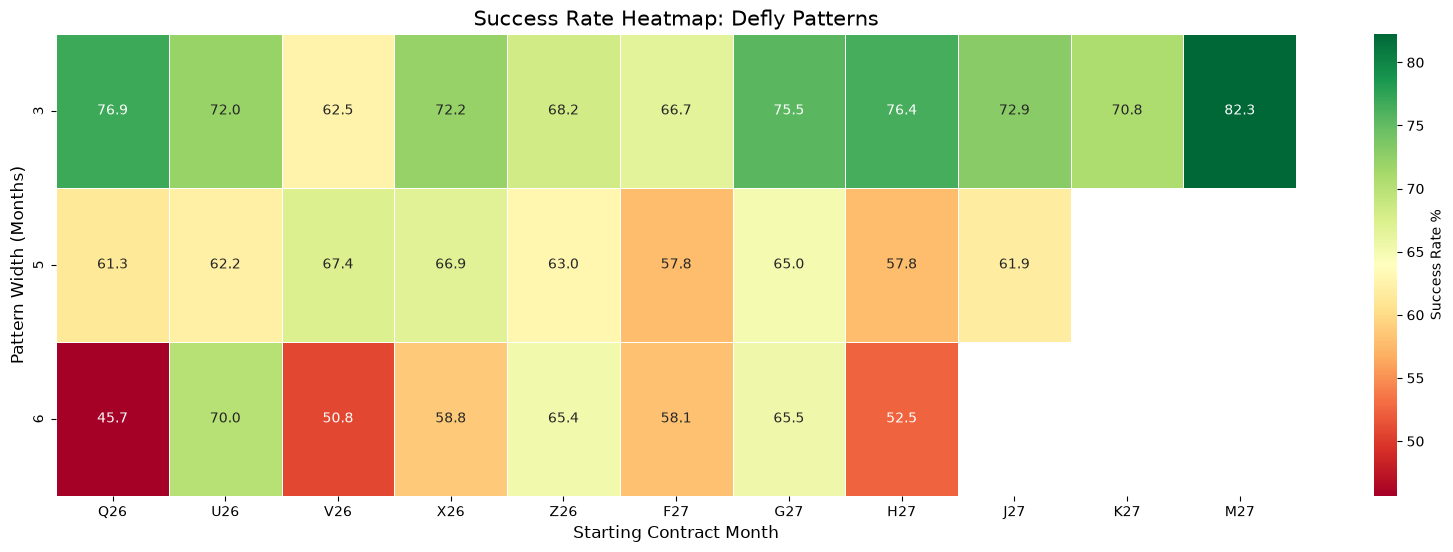

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import re

# 1. Helper to extract Start Contract, Pattern Width (for Rows), and Chronological Sort Key
MONTHS = "FGHJKMNQUVXZ"
def parse_expr(expr):
    matches = re.findall(r"([FGHJKMNQUVXZ])(\d{2})", expr)
    s_m, s_y = matches[0][0], int(matches[0][1])
    e_m, e_y = matches[-1][0], int(matches[-1][1])
    
    start_abs = s_y * 12 + MONTHS.find(s_m)
    end_abs = e_y * 12 + MONTHS.find(e_m)
    
    return f"{s_m}{s_y:02d}", (end_abs - start_abs), start_abs

# 2. Process Data
df_h = df_summary.copy()
df_h[['Start', 'Pattern_Row', 'Sort_Key']] = df_h['Expression'].apply(lambda x: pd.Series(parse_expr(x)))

# 3. Pivot and Sort Chronologically
pivot = df_h.pivot(index='Pattern_Row', columns='Start', values='Success_Rate')
sorted_cols = sorted(pivot.columns, key=lambda c: int(c[1:]) * 12 + MONTHS.find(c[0]))
pivot = pivot[sorted_cols].sort_index()

# 4. Plot Heatmap
plt.figure(figsize=(20, 6))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="RdYlGn", linewidths=0.5, cbar_kws={'label': 'Success Rate %'})
plt.title("Success Rate Heatmap: Defly Patterns", fontsize=15)
plt.xlabel("Starting Contract Month", fontsize=12)
plt.ylabel("Pattern Width (Months)", fontsize=12)
plt.show()

In [ ]:
# import json
# from Mini_Tools.expression import months_to_expression

# with open("combinations.json", "r") as f:
#     data = json.load(f)

# expressions = []

# for strategy, combos in data.items():

#     print(f"\n{strategy}")

#     for combo in combos:

#         expr = months_to_expression(combo)

#         expressions.append(expr)

#         print(expr)